<a href="https://colab.research.google.com/github/JosNavarro/Invest2026-27/blob/main/GRUPISA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import gc
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import h5py
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt


from google.colab import drive
drive.mount('/content/drive')

data_path = '/content/drive/My Drive/PI26/NASADATASET/1. BatteryAgingARC-FY08Q4/ChargePartitions/B0006train.mat'
battery_id_train = 'B0006'

Mounted at /content/drive


In [3]:
def graficar_modelo(actual, predicted, battery_id, r2_score):
    """
    Genera la gráfica de degradación con fondo blanco y estilo clásico,
    exactamente igual a la imagen de referencia.
    """
    # Usar el mismo tamaño ancho que en tu imagen
    fig, ax = plt.subplots(figsize=(12, 7))

    # Fondo blanco
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # Curvas de datos: Azul (Real) y Rojo (Predicción)
    ax.plot(actual, label=f'Actual Capacity (NASA {battery_id})', color='blue', linewidth=2)
    ax.plot(predicted, label='GRU Predicted Capacity', color='red', linewidth=2)

    # Umbral de Fin de Vida (Línea punteada negra)
    ax.axhline(y=1.4, color='black', linestyle=':', label='End of Life Threshold (1.4 Ah)')

    # Título y etiquetas con texto en negro
    ax.set_title(f'Battery Degradation: Actual vs. GRU Prediction ($R^2$: {r2_score:.4f})', color='black', fontsize=13)
    ax.set_xlabel('Cycles (Sliding Windows)', color='black', fontsize=11)
    ax.set_ylabel('Capacity (Ah)', color='black', fontsize=11)

    # Configuración de ejes
    ax.tick_params(colors='black')

    # Leyenda en la esquina superior derecha con fondo blanco
    ax.legend(facecolor='white', edgecolor='lightgray', labelcolor='black', loc='upper right')

    # Cuadrícula: Líneas punteadas grises
    ax.grid(True, linestyle='--', color='silver', alpha=0.8)

    # Bordes del gráfico en negro
    for spine in ax.spines.values():
        spine.set_edgecolor('black')

    plt.tight_layout()
    plt.show()

In [4]:
with h5py.File(data_path, 'r') as f:
  X_raw = np.array(f['X_3D'])
  cap_min = np.array(f['cap_min']).item()
  cap_max = np.array(f['cap_max']).item()

In [5]:
# h5py reads it as [features, window_size, windows]
# We transpose it back to [windows, window_size, features] -> (2, 1, 0)
X_corrected = np.transpose(X_raw, (2, 1, 0))
print(f"Corrected Tensor shape: {X_corrected.shape}")

Corrected Tensor shape: (50236, 50, 8)


In [6]:
# ==========================================
# 1. Preparación de los Tensores (Fuga de Datos Corregida)
# ==========================================
print("Preparando datos de entrenamiento...")
# Asegúrate de que X_corrected sea el tensor transpuesto de tu B0005
X_train_data = X_corrected[:, :, :7] # SOLO columnas 0 a 6 (Sensores)
Y_train_data = X_corrected[:, -1, 7] # SOLO columna 7 del último ciclo (Capacidad)

X_train_tensor = torch.tensor(X_train_data, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train_data, dtype=torch.float32).unsqueeze(1)

print(f"Tensor X (Entrada): {X_train_tensor.shape} -> [Ventanas, 50 ciclos, 7 features]")
print(f"Tensor Y (Objetivo): {Y_train_tensor.shape} -> [Ventanas, 1 predicción]")

# Crear el DataLoader para procesar en lotes de 64
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

Preparando datos de entrenamiento...
Tensor X (Entrada): torch.Size([50236, 50, 7]) -> [Ventanas, 50 ciclos, 7 features]
Tensor Y (Objetivo): torch.Size([50236, 1]) -> [Ventanas, 1 predicción]


In [19]:
class SAPI_AGRU(nn.Module):
    def __init__(self, input_size=7, hidden_size=64, num_layers=2, output_size=1):
        super(SAPI_AGRU, self).__init__()

        # Gated Recurrent Unit (GRU)
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)

        # Soft Attention Mechanism
        self.attention = nn.Linear(hidden_size, 1)

        # Capa de salida
        self.fc = nn.Linear(hidden_size, output_size)

        # ==========================================
        # PARÁMETROS FÍSICOS (Ecuación de Verhulst)
        # ==========================================
        self.r = nn.Parameter(torch.tensor([-0.01]))
        self.K = nn.Parameter(torch.tensor([1.0]))

        # ==========================================
        # PESOS AUTO-ADAPTATIVOS (Ecuación 7 del Paper)
        # ==========================================
        # log_lambda_u: Peso para L_u (Datos). Inicializado en -2.0 hace que exp(2) le dé mucha prioridad al inicio.
        self.log_lambda_u = nn.Parameter(torch.tensor([-2.0]))
        # log_lambda_r: Peso para L_r (Física). Inicializado en 2.0 hace que exp(-2) no estorbe al inicio.
        self.log_lambda_r = nn.Parameter(torch.tensor([2.0]))

    def forward(self, x):
        # 1. Pasar por la GRU
        gru_out, _ = self.gru(x)

        # 2. Mecanismo de Atención
        attn_scores = self.attention(gru_out)
        attn_weights = F.softmax(attn_scores, dim=1)
        context_vector = torch.sum(gru_out * attn_weights, dim=1)

        # 3. Predicción Final (Capacidad)
        prediction = self.fc(context_vector)
        return prediction

In [20]:
# ==========================================
# 1. Preparación de los Tensores (Fuga de Datos Corregida)
# ==========================================
print("Preparando datos de entrenamiento...")
# Asegúrate de que X_corrected sea el tensor transpuesto de tu B0005
X_train_data = X_corrected[:, :, :7] # SOLO columnas 0 a 6 (Sensores)
Y_train_data = X_corrected[:, -1, 7] # SOLO columna 7 del último ciclo (Capacidad)

X_train_tensor = torch.tensor(X_train_data, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train_data, dtype=torch.float32).unsqueeze(1)

print(f"Tensor X (Entrada): {X_train_tensor.shape} -> [Ventanas, 50 ciclos, 7 features]")
print(f"Tensor Y (Objetivo): {Y_train_tensor.shape} -> [Ventanas, 1 predicción]")

# Crear el DataLoader para procesar en lotes de 64
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

Preparando datos de entrenamiento...
Tensor X (Entrada): torch.Size([50236, 50, 7]) -> [Ventanas, 50 ciclos, 7 features]
Tensor Y (Objetivo): torch.Size([50236, 1]) -> [Ventanas, 1 predicción]


In [21]:
# ==========================================
# 2. Configuración del Modelo y Optimizador
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

# Instanciamos el modelo con input_size=7
model = SAPI_AGRU(input_size=7, hidden_size=64, num_layers=2, output_size=1).to(device)

# Función de pérdida (MSE) y Optimizador (Adam)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay = 1e-5)

Entrenando en: cuda


In [22]:
# ==========================================
# 3. Bucle de Entrenamiento
# ==========================================
num_epochs = 50

print("Iniciando entrenamiento SA-PI-AGRU (Metodología estricta del paper)...")
model.train()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs):
    epoch_loss_total = 0.0
    epoch_loss_data = 0.0
    epoch_loss_phys = 0.0

    for batch_X, batch_Y in train_loader:
        batch_X = batch_X.to(device)
        batch_Y = batch_Y.to(device)

        # Requisito indispensable para el AutoDiff (Ecuación 1)
        batch_X.requires_grad_(True)
        optimizer.zero_grad()

        # Apagamos CuDNN localmente para permitir el cálculo de segundas derivadas en la GRU
        with torch.backends.cudnn.flags(enabled=False):
            predictions = model(batch_X)

        # ==========================================
        # CÁLCULO DE DERIVADAS (AutoDiff)
        # ==========================================
        dC_dx = torch.autograd.grad(
            outputs=predictions,
            inputs=batch_X,
            grad_outputs=torch.ones_like(predictions),
            create_graph=True,
            retain_graph=True
        )[0]

        # Extraemos la derivada de la Capacidad respecto al tiempo (asumiendo que 'Ciclo' es el índice 0)
        dC_dt = dC_dx[:, -1, 0].unsqueeze(1)

        # ==========================================
        # COMPONENTE FÍSICO (L_r) - Ecuación de Verhulst
        # ==========================================
        residuo_fisico = dC_dt - (model.r * predictions * (1.0 - predictions / model.K))
        L_r = torch.mean(residuo_fisico ** 2)

        # ==========================================
        # COMPONENTE DE DATOS (L_u)
        # ==========================================
        L_u = criterion(predictions, batch_Y)

        # ==========================================
        # PÉRDIDA ADP-BAL (Ecuación 7 del Paper)
        # L = exp(-lambda_u')*L_u + exp(-lambda_r')*L_r + lambda_u' + lambda_r'
        # ==========================================
        loss_total = (torch.exp(-model.log_lambda_u) * L_u + model.log_lambda_u) + \
                     (torch.exp(-model.log_lambda_r) * L_r + model.log_lambda_r)

        # Backpropagation
        loss_total.backward()

        # Evita que los pesos adaptativos o la GRU tengan gradientes explosivos
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss_total += loss_total.item()
        epoch_loss_data += L_u.item()
        epoch_loss_phys += L_r.item()

    # Imprimir progreso cada 5 épocas
    if (epoch + 1) % 5 == 0 or epoch == 0:
        avg_data = epoch_loss_data / len(train_loader)
        avg_phys = epoch_loss_phys / len(train_loader)

        peso_u_actual = torch.exp(-model.log_lambda_u).item()
        peso_r_actual = torch.exp(-model.log_lambda_r).item()

        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'  L_data (u): {avg_data:.6f} | Peso exp(-λu): {peso_u_actual:.4f}')
        print(f'  L_phys (r): {avg_phys:.6f} | Peso exp(-λr): {peso_r_actual:.4f}')
        print('-'*50)

Iniciando entrenamiento SA-PI-AGRU (Metodología estricta del paper)...
Epoch [1/50]
  L_data (u): 0.003926 | Peso exp(-λu): 16.2420
  L_phys (r): 0.000000 | Peso exp(-λr): 0.2954
--------------------------------------------------
Epoch [5/50]
  L_data (u): 0.000815 | Peso exp(-λu): 153.0734
  L_phys (r): 0.000001 | Peso exp(-λr): 2.9234
--------------------------------------------------
Epoch [10/50]
  L_data (u): 0.000472 | Peso exp(-λu): 786.5265
  L_phys (r): 0.000001 | Peso exp(-λr): 18.3125
--------------------------------------------------
Epoch [15/50]
  L_data (u): 0.000364 | Peso exp(-λu): 2535.2947
  L_phys (r): 0.000004 | Peso exp(-λr): 123.3074
--------------------------------------------------
Epoch [20/50]
  L_data (u): 0.000328 | Peso exp(-λu): 3656.6189
  L_phys (r): 0.000004 | Peso exp(-λr): 1570.0914
--------------------------------------------------
Epoch [25/50]
  L_data (u): 0.000299 | Peso exp(-λu): 4181.7046
  L_phys (r): 0.000000 | Peso exp(-λr): 35752.4844
----

In [23]:
# ==========================================
# 4. Inferencia sobre los datos de Entrenamiento (OOM Safe)
# ==========================================
# Limpiar memoria de la GPU
torch.cuda.empty_cache()
gc.collect()

print("Generando predicciones finales sobre los datos de entrenamiento...")
model.eval()
all_train_predictions = []
batch_size = 256 # Tamaño de bocado seguro
num_train_samples = X_train_tensor.shape[0]

with torch.no_grad():
    for i in range(0, num_train_samples, batch_size):
        batch_X = X_train_tensor[i : i + batch_size].to(device)
        batch_preds = model(batch_X)
        all_train_predictions.append(batch_preds.cpu().numpy())

train_preds_numpy = np.concatenate(all_train_predictions, axis=0)

Generando predicciones finales sobre los datos de entrenamiento...


In [24]:
# ==========================================
# 5. Desnormalizar Datos
# ==========================================
# Regresar los valores de la escala 0-1 a la escala real (Amperios-hora)
# NOTA: Asegúrate de que las variables cap_max y cap_min estén cargadas en memoria
actual_train_capacity = (Y_train_data * (cap_max - cap_min)) + cap_min
predicted_train_capacity = (train_preds_numpy.flatten() * (cap_max - cap_min)) + cap_min

In [25]:
# ==========================================
# 6. Calcular las 4 Métricas de Rendimiento
# ==========================================
train_mse = mean_squared_error(actual_train_capacity, predicted_train_capacity)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(actual_train_capacity, predicted_train_capacity)
train_r2 = r2_score(actual_train_capacity, predicted_train_capacity)

# Imprimir el reporte
print("-" * 40)
print(f"REPORTE DE RENDIMIENTO: Batería B0005 (ENTRENAMIENTO)")
print("-" * 40)
print(f"MSE  (Mean Squared Error):      {train_mse:.6f}")
print(f"RMSE (Root Mean Squared Error): {train_rmse:.6f} Ah")
print(f"MAE  (Mean Absolute Error):     {train_mae:.6f} Ah")
print(f"R^2  (R-Squared):               {train_r2:.4f}")
print("-" * 40)

----------------------------------------
REPORTE DE RENDIMIENTO: Batería B0005 (ENTRENAMIENTO)
----------------------------------------
MSE  (Mean Squared Error):      0.000085
RMSE (Root Mean Squared Error): 0.009199 Ah
MAE  (Mean Absolute Error):     0.005847 Ah
R^2  (R-Squared):               0.9984
----------------------------------------


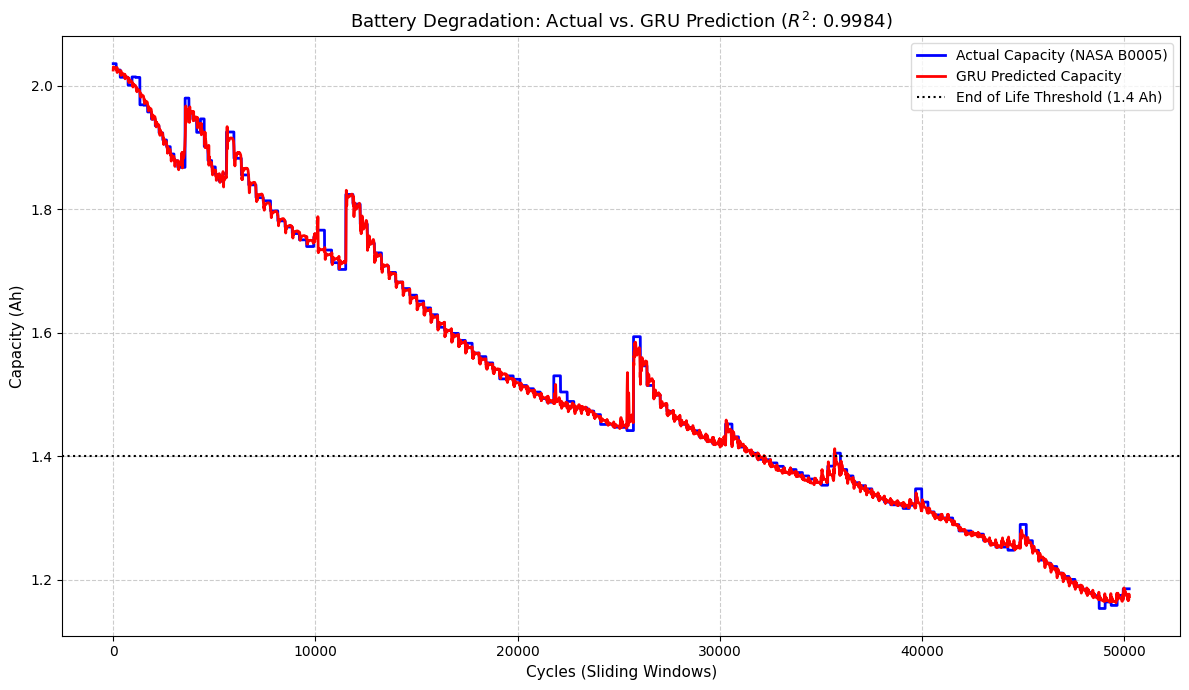

In [26]:
# ==========================================
# 7. Visualización Final (Predicción vs Realidad)
# ==========================================
# ... (código donde calculas train_r2, train_mse, etc.) ...

# Llamada a la función maestra
graficar_modelo(actual_train_capacity, predicted_train_capacity, 'B0005', train_r2)

# Evaluation with other datasets


In [27]:
# ==========================================
# CONFIGURACIÓN INICIAL (Testing)
# ==========================================
battery_id = 'B0007'
test_file_path = f'/content/drive/My Drive/PI26/NASADATASET/1. BatteryAgingARC-FY08Q4/ChargePartitions/{battery_id}test.mat'

# ==========================================
# 1. Cargar Datos desde MATLAB
# ==========================================
print(f"Cargando archivo: {test_file_path}...")
with h5py.File(test_file_path, 'r') as f:
    X_raw_test = np.array(f['X_3D'])
    # Recuperamos los parámetros de normalización de la base maestra
    cap_min = np.array(f['cap_min']).item()
    cap_max = np.array(f['cap_max']).item()



Cargando archivo: /content/drive/My Drive/PI26/NASADATASET/1. BatteryAgingARC-FY08Q4/ChargePartitions/B0007test.mat...


In [28]:
# ==========================================
# 2. Corregir Formato y Separar Datos (Fuga de Datos Corregida)
# ==========================================
# ¡ESTE ES EL PASO QUE FALTABA! Arregla el orden de las dimensiones de MATLAB a Python
X_corrected_test = np.transpose(X_raw_test, (2, 1, 0))
print(f"Forma original del tensor (corregida): {X_corrected_test.shape}")

# Separamos los 7 sensores (Entrada) de la Capacidad Real (Objetivo)
X_test_data = X_corrected_test[:, :, :7]
Y_test_data = X_corrected_test[:, -1, 7]

# Convertimos a tensores de PyTorch
X_test_tensor = torch.tensor(X_test_data, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test_data, dtype=torch.float32).unsqueeze(1)


Forma original del tensor (corregida): (50236, 50, 8)


In [29]:
# ==========================================
# 2. Inferencia por Lotes (OOM Safe)
# ==========================================
# Limpiamos la memoria de la tarjeta gráfica
torch.cuda.empty_cache()
gc.collect()

print(f"Generando predicciones para la batería {battery_id}...")
model.eval()
all_predictions = []
batch_size = 256 # Tamaño de lote seguro para la memoria
num_samples = X_test_tensor.shape[0]

with torch.no_grad():
    for i in range(0, num_samples, batch_size):
        batch_X = X_test_tensor[i : i + batch_size].to(device)
        batch_preds = model(batch_X)
        all_predictions.append(batch_preds.cpu().numpy())

# Unimos todas las predicciones
preds_numpy = np.concatenate(all_predictions, axis=0)

Generando predicciones para la batería B0007...


In [30]:
# ==========================================
# 3. Desnormalizar Datos
# ==========================================
# Regresamos los valores a su escala original de Amperios-hora (Ah)
# (Asegúrate de que cap_max y cap_min de tu base B0005 estén cargados en memoria)
actual_capacity = (Y_test_data * (cap_max - cap_min)) + cap_min
predicted_capacity = (preds_numpy.flatten() * (cap_max - cap_min)) + cap_min

In [31]:
# ==========================================
# 4. Calcular Métricas de Rendimiento
# ==========================================
test_mse = mean_squared_error(actual_capacity, predicted_capacity)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(actual_capacity, predicted_capacity)
test_r2 = r2_score(actual_capacity, predicted_capacity)

print("-" * 40)
print(f"REPORTE DE RENDIMIENTO: Batería {battery_id} (TESTING)")
print("-" * 40)
print(f"MSE  (Mean Squared Error):      {test_mse:.6f}")
print(f"RMSE (Root Mean Squared Error): {test_rmse:.6f} Ah")
print(f"MAE  (Mean Absolute Error):     {test_mae:.6f} Ah")
print(f"R^2  (R-Squared):               {test_r2:.4f}")
print("-" * 40)

----------------------------------------
REPORTE DE RENDIMIENTO: Batería B0007 (TESTING)
----------------------------------------
MSE  (Mean Squared Error):      0.013412
RMSE (Root Mean Squared Error): 0.115812 Ah
MAE  (Mean Absolute Error):     0.104614 Ah
R^2  (R-Squared):               0.4241
----------------------------------------


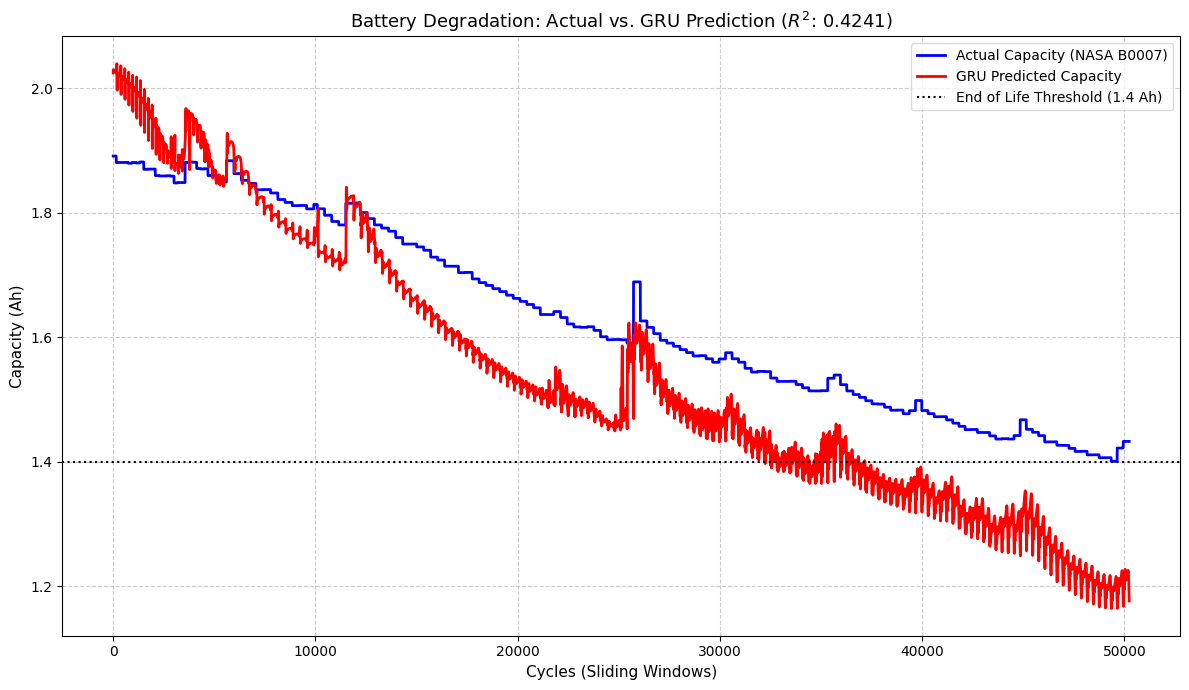

In [32]:
# ==========================================
# 5. Visualización Final (Formato Clásico Blanco)
# ==========================================


graficar_modelo(actual_capacity, predicted_capacity, battery_id, test_r2)